In [2]:
# 这行代码将你的Google Drive挂载到Colab虚拟机上
from google.colab import drive
drive.mount('/content/drive')

# 待办：在你的Drive中输入保存了解压后的作业文件夹的路径
FOLDERNAME = 'cs231n/assignments/assignment2/'
assert FOLDERNAME is not None, "[!] 请输入文件夹名称。"

import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# 如果CIFAR-10数据集尚未存在，下载数据集
%cd /content/drive/My\ Drive/$FOLDERNAME/cs231n/datasets/
!bash get_datasets.sh

# 修正后的切换目录：移除行内注释以避免路径解析错误
%cd /content/drive/My\ Drive/$FOLDERNAME

Mounted at /content/drive
/content/drive/My Drive/cs231n/assignments/assignment2/cs231n/datasets
/content/drive/My Drive/cs231n/assignments/assignment2


#  dropout（随机失活）

dropout[1]是一种通过在正向传播过程中随机将一些输出激活值设为零来正则化神经网络的技术。在本练习中，你需要实现一个dropout层，并修改你的全连接网络以选择性地使用dropout。

[1] [Geoffrey E. Hinton et al, "Improving neural networks by preventing co-adaptation of feature detectors", arXiv 2012](https://arxiv.org/abs/1207.0580)

In [4]:
# 配置单元格
import os
import sys
import time
import numpy as np
import matplotlib.pyplot as plt

# 确保当前目录在sys.path中，以便导入cs231n
if '/content/drive/My Drive/' + FOLDERNAME not in sys.path:
    sys.path.append('/content/drive/My Drive/' + FOLDERNAME)

from cs231n.classifiers.fc_net import *
from cs231n.data_utils import get_CIFAR10_data
from cs231n.gradient_check import eval_numerical_gradient, eval_numerical_gradient_array
from cs231n.solver import Solver

# 设置matplotlib在 notebook 中内联显示
%matplotlib inline
plt.rcParams["figure.figsize"] = (10.0, 8.0)
plt.rcParams["image.interpolation"] = "nearest"
plt.rcParams["image.cmap"] = "gray"

%load_ext autoreload
%autoreload 2

def rel_error(x, y):
    """返回相对误差"""
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
# 加载（预处理后的）CIFAR-10数据
data = get_CIFAR10_data()
# 遍历数据字典中的所有键值对并打印
for k, v in list(data.items()):
    print(f"{k}：{v.shape}")  # 打印每个数据集的名称及其形状

X_train：(49000, 3, 32, 32)
y_train：(49000,)
X_val：(1000, 3, 32, 32)
y_val：(1000,)
X_test：(1000, 3, 32, 32)
y_test：(1000,)


# Dropout：前向传播

在文件`cs231n/layers.py`中，实现dropout的前向传播。由于dropout在训练模式和测试模式下的行为不同，要确保为两种模式都实现相应的操作。

完成实现后，运行下面的单元格来测试你的代码。

In [6]:
np.random.seed(231)  # 设置随机种子，保证结果可复现
x = np.random.randn(500, 500) + 10  # 生成随机输入数据，均值约为10，形状为(500, 500)

# 测试不同的dropout概率p
for p in [0.25, 0.4, 0.7]:
    # 训练模式下的dropout前向传播（p为保留神经元的概率）
    out, _ = dropout_forward(x, {'mode': 'train', 'p': p})
    # 测试模式下的dropout前向传播
    out_test, _ = dropout_forward(x, {'mode': 'test', 'p': p})

    print('测试 p = ', p, ' 时的情况')
    print('输入数据的均值：', x.mean())
    print('训练模式下输出的均值：', out.mean())
    print('测试模式下输出的均值：', out_test.mean())
    print('训练模式下输出中被设为0的比例：', (out == 0).mean())
    print('测试模式下输出中被设为0的比例：', (out_test == 0).mean())
    print()  # 空行分隔不同p的测试结果

测试 p =  0.25  时的情况
输入数据的均值： 10.000207878477502
训练模式下输出的均值： 10.014059116977283
测试模式下输出的均值： 10.000207878477502
训练模式下输出中被设为0的比例： 0.749784
测试模式下输出中被设为0的比例： 0.0

测试 p =  0.4  时的情况
输入数据的均值： 10.000207878477502
训练模式下输出的均值： 9.977917658761159
测试模式下输出的均值： 10.000207878477502
训练模式下输出中被设为0的比例： 0.600796
测试模式下输出中被设为0的比例： 0.0

测试 p =  0.7  时的情况
输入数据的均值： 10.000207878477502
训练模式下输出的均值： 9.987811912159426
测试模式下输出的均值： 10.000207878477502
训练模式下输出中被设为0的比例： 0.30074
测试模式下输出中被设为0的比例： 0.0



# Dropout：反向传播

在文件`cs231n/layers.py`中，实现dropout的反向传播。完成后，运行以下单元格，通过数值梯度检查来验证你的实现。

In [7]:
np.random.seed(231)  # 设置随机种子，确保结果可复现
x = np.random.randn(10, 10) + 10  # 生成随机输入数据，均值约为10，形状为(10, 10)
dout = np.random.randn(*x.shape)  # 生成与x形状相同的随机输出梯度

# dropout参数：训练模式，保留概率p=0.2，随机种子123（保证dropout掩码固定）
dropout_param = {'mode': 'train', 'p': 0.2, 'seed': 123}
out, cache = dropout_forward(x, dropout_param)  # 执行dropout前向传播，获取输出和缓存
dx = dropout_backward(dout, cache)  # 执行dropout反向传播，计算输入梯度dx
# 用数值方法计算梯度作为参考（数值梯度）
dx_num = eval_numerical_gradient_array(lambda xx: dropout_forward(xx, dropout_param)[0], x, dout)

# 误差应在1e-10左右或更小
print('dx的相对误差：', rel_error(dx, dx_num))

dx的相对误差： 5.44560814873387e-11


## 内联问题1：
如果在dropout层中，不将通过反向dropout的数值除以`p`，会发生什么？为什么会出现这种情况？

## 答案：
这个就好像是随机可汗大点兵，例如说p是0.5，那等于就是抽取了一半的人干活。那如果除以p，等于就是只干了一半的活，可我们是要这些人全干。这一半的活输入到下一层，会让下一层适应。如果我把dropout关掉，那么就会直接爆炸，数据会大漂移


# 带Dropout的全连接网络

在文件`cs231n/classifiers/fc_net.py`中，修改你的实现以使用dropout。具体来说，如果网络的构造函数收到的`dropout_keep_ratio`参数值不是1，那么网络应该在每个ReLU非线性激活之后立即添加一个dropout层。完成后，运行以下代码通过数值梯度检查来验证你的实现。

In [8]:
np.random.seed(231)  # 设置随机种子，确保结果可复现
# N：批量大小，D：输入维度，H1：第一层隐藏层大小，H2：第二层隐藏层大小，C：类别数
N, D, H1, H2, C = 2, 15, 20, 30, 10
X = np.random.randn(N, D)  # 生成随机输入数据
y = np.random.randint(C, size=(N,))  # 生成随机标签

# 测试不同的dropout保留比例
for dropout_keep_ratio in [1, 0.75, 0.5]:
    print('测试 dropout = ', dropout_keep_ratio, ' 时的情况')
    # 创建全连接网络模型
    model = FullyConnectedNet(
        [H1, H2],  # 隐藏层大小列表
        input_dim=D,  # 输入维度
        num_classes=C,  # 类别数
        weight_scale=5e-2,  # 权重初始化缩放因子
        dtype=np.float64,  # 数据类型
        dropout_keep_ratio=dropout_keep_ratio,  # dropout保留比例
        seed=123  # 随机种子，保证dropout行为可复现
    )

    loss, grads = model.loss(X, y)  # 计算损失和梯度
    print('初始损失：', loss)

    # 相对误差应在1e-6左右或更小
    # 注意：当dropout_keep_ratio=1时，W2的误差在1e-5量级左右是可接受的
    for name in sorted(grads):
        # 定义一个仅返回损失的函数，用于数值梯度计算
        f = lambda _: model.loss(X, y)[0]
        # 数值计算梯度
        grad_num = eval_numerical_gradient(f, model.params[name], verbose=False, h=1e-5)
        # 打印梯度的相对误差
        print('%s 的相对误差：%.2e' % (name, rel_error(grad_num, grads[name])))
    print()  # 空行分隔不同dropout保留比例的测试结果

测试 dropout =  1  时的情况
初始损失： 2.300479089768492
W1 的相对误差：1.03e-07
W2 的相对误差：2.21e-05
W3 的相对误差：4.56e-07
b1 的相对误差：4.66e-09
b2 的相对误差：2.09e-09
b3 的相对误差：1.69e-10

测试 dropout =  0.75  时的情况
初始损失： 2.302371489704412
W1 的相对误差：1.85e-07
W2 的相对误差：2.15e-06
W3 的相对误差：4.56e-08
b1 的相对误差：1.16e-08
b2 的相对误差：1.82e-09
b3 的相对误差：1.48e-10

测试 dropout =  0.5  时的情况
初始损失： 2.30427592207859
W1 的相对误差：3.11e-07
W2 的相对误差：2.48e-08
W3 的相对误差：6.43e-08
b1 的相对误差：5.37e-09
b2 的相对误差：1.91e-09
b3 的相对误差：1.85e-10



# 正则化实验

作为一项实验，我们将在500个训练样本上训练两个双层网络：一个不使用dropout，另一个使用0.25的保留概率。然后我们将可视化这两个网络随时间变化的训练准确率和验证准确率。

In [9]:
# 训练两个相同的网络，一个使用dropout，一个不使用
np.random.seed(231)  # 设置随机种子，确保实验可复现
num_train = 500  # 训练样本数量
small_data = {
    'X_train': data['X_train'][:num_train],  # 取前500个训练样本
    'y_train': data['y_train'][:num_train],
    'X_val': data['X_val'],  # 验证集数据
    'y_val': data['y_val'],
}

solvers = {}  # 用于存储不同dropout设置的求解器
dropout_choices = [1, 0.25]  # 测试两种dropout保留比例：1（无dropout）和0.25
for dropout_keep_ratio in dropout_choices:
    # 创建全连接网络模型，包含一个500维的隐藏层
    model = FullyConnectedNet(
        [500],
        dropout_keep_ratio=dropout_keep_ratio  # 设置dropout保留比例
    )
    print(dropout_keep_ratio)  # 打印当前的dropout保留比例

    # 创建求解器用于训练模型
    solver = Solver(
        model,  # 要训练的模型
        small_data,  # 使用的数据集
        num_epochs=25,  # 训练轮数
        batch_size=100,  # 批大小
        update_rule='adam',  # 使用adam优化算法
        optim_config={'learning_rate': 5e-4,},  # 优化器配置，学习率为5e-4
        verbose=True,  # 训练过程中打印详细信息
        print_every=100  # 每100次迭代打印一次信息
    )
    solver.train()  # 训练模型
    solvers[dropout_keep_ratio] = solver  # 将训练好的求解器存入字典
    print()  # 空行分隔不同dropout设置的训练过程

1
(迭代 1 / 125) 损失: 7.856644
(Epoch 0 / 25) 训练准确率: 0.260000; 验证准确率: 0.184000


/content/drive/My Drive/cs231n/assignments/assignment2/cs231n/layers.py:131: RuntimeWarning: divide by zero encountered in log
  logp = np.log(p)


(Epoch 1 / 25) 训练准确率: 0.416000; 验证准确率: 0.258000
(Epoch 2 / 25) 训练准确率: 0.482000; 验证准确率: 0.276000
(Epoch 3 / 25) 训练准确率: 0.532000; 验证准确率: 0.277000
(Epoch 4 / 25) 训练准确率: 0.600000; 验证准确率: 0.271000
(Epoch 5 / 25) 训练准确率: 0.710000; 验证准确率: 0.298000
(Epoch 6 / 25) 训练准确率: 0.720000; 验证准确率: 0.282000
(Epoch 7 / 25) 训练准确率: 0.832000; 验证准确率: 0.255000
(Epoch 8 / 25) 训练准确率: 0.874000; 验证准确率: 0.267000
(Epoch 9 / 25) 训练准确率: 0.898000; 验证准确率: 0.276000
(Epoch 10 / 25) 训练准确率: 0.900000; 验证准确率: 0.262000
(Epoch 11 / 25) 训练准确率: 0.934000; 验证准确率: 0.269000
(Epoch 12 / 25) 训练准确率: 0.966000; 验证准确率: 0.298000
(Epoch 13 / 25) 训练准确率: 0.974000; 验证准确率: 0.306000
(Epoch 14 / 25) 训练准确率: 0.968000; 验证准确率: 0.320000
(Epoch 15 / 25) 训练准确率: 0.978000; 验证准确率: 0.300000
(Epoch 16 / 25) 训练准确率: 0.986000; 验证准确率: 0.307000
(Epoch 17 / 25) 训练准确率: 0.974000; 验证准确率: 0.308000
(Epoch 18 / 25) 训练准确率: 0.970000; 验证准确率: 0.308000
(Epoch 19 / 25) 训练准确率: 0.984000; 验证准确率: 0.279000
(Epoch 20 / 25) 训练准确率: 0.980000; 验证准确率: 0.293000
(迭代 101 / 125) 损失: 0.449588
(

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 30830 (\N{CJK UNIFIED IDEOGRAPH-786E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  fig.canvas

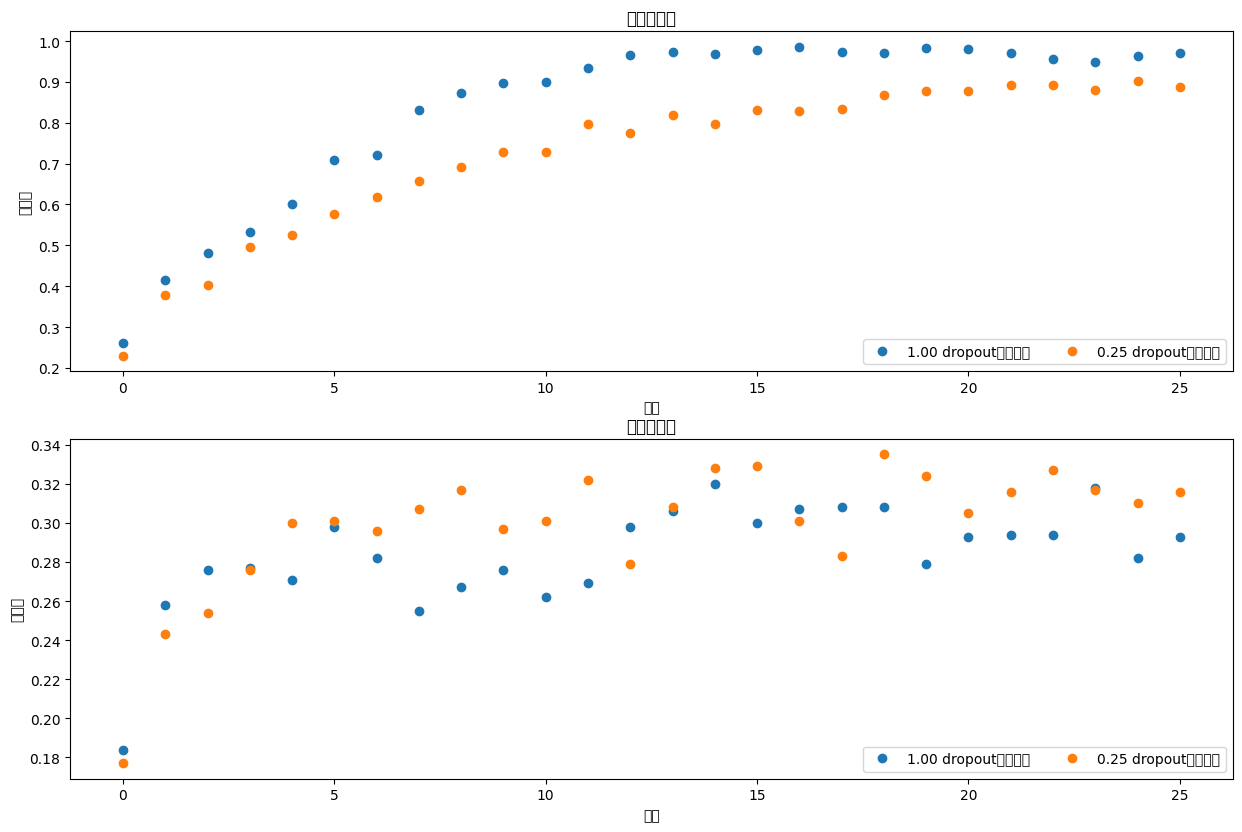

In [10]:
# 绘制两个模型的训练准确率和验证准确率
train_accs = []  # 存储训练准确率
val_accs = []    # 存储验证准确率
for dropout_keep_ratio in dropout_choices:
    solver = solvers[dropout_keep_ratio]
    train_accs.append(solver.train_acc_history[-1])  # 取最后一轮的训练准确率
    val_accs.append(solver.val_acc_history[-1])      # 取最后一轮的验证准确率

plt.subplot(3, 1, 1)  # 创建3行1列的子图，当前绘制第1个
for dropout_keep_ratio in dropout_choices:
    # 绘制训练准确率曲线，标记为'o'，标签为对应的dropout保留比例
    plt.plot(
        solvers[dropout_keep_ratio].train_acc_history, 'o', label='%.2f dropout保留比例' % dropout_keep_ratio)
plt.title('训练准确率')
plt.xlabel('轮次')
plt.ylabel('准确率')
plt.legend(ncol=2, loc='lower right')  # 图例显示在右下角，2列

plt.subplot(3, 1, 2)  # 当前绘制第2个子图
for dropout_keep_ratio in dropout_choices:
    # 绘制验证准确率曲线，标记为'o'，标签为对应的dropout保留比例
    plt.plot(
        solvers[dropout_keep_ratio].val_acc_history, 'o', label='%.2f dropout保留比例' % dropout_keep_ratio)
plt.title('验证准确率')
plt.xlabel('轮次')
plt.ylabel('准确率')
plt.legend(ncol=2, loc='lower right')  # 图例显示在右下角，2列

plt.gcf().set_size_inches(15, 15)  # 设置图表大小
plt.show()  # 显示图表

## 内联问题2：
比较使用dropout和不使用dropout时的验证准确率与训练准确率——你的结果说明了dropout作为正则化器有什么作用？

## 答案：
dropout作为正则化器可以削弱神经元之间互相依赖的现象，强迫每个神经元都去学校整体的特征，而不是依赖于某一个特定的神经元。而dropout会给网络制造大量的噪声，网络为了得出正确的答案就必须去关注于整体的特征，以防止过拟合
